# 11. Backbone 모델 — delta_days 예측

**태스크**: 식물 이미지 + 센서 데이터 → `delta_days`(성장 일수) 회귀

**모델**: EfficientNet-B0 (vision) + MLP (sensor) 멀티모달

**입력(X)**
- 이미지: `photos/` JPEG (RGB)
- 센서: `air_temperature`, `air_humidity`, `light`, `soil_temperature`, `soil_moisture`, `soil_ph`, `soil_ec`, `soil_nitrogen`, `soil_phosphorus`, `soil_potassium` (10개)

**레이블(Y)**: `delta_days` (연속값, 0 ~ ~7)

> `time`, `datetime` 등 시간 관련 컬럼은 입력에 포함하지 않습니다.

In [1]:
import os
import random
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

import matplotlib.pyplot as plt

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    DATA_DIR = Path('/content/dataset/collector')
else:
    DATA_DIR = Path(os.getcwd()).parent / 'dataset' / 'collector'

print(f'DATA_DIR: {DATA_DIR}')

DATA_DIR: /Users/mainframe/Workspace/Graduate/dataset/collector


In [2]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f'Seed: {seed}')

set_seed(42)

Seed: 42


## 1. 데이터 로드

In [3]:
df_train = pq.read_table(DATA_DIR / 'train.parquet').to_pandas()
df_val   = pq.read_table(DATA_DIR / 'val.parquet').to_pandas()
df_test  = pq.read_table(DATA_DIR / 'test.parquet').to_pandas()

norm_stats = pq.read_table(DATA_DIR / 'sensor_norm_stats.parquet').to_pandas()

print(f'train: {len(df_train)}  val: {len(df_val)}  test: {len(df_test)}')
print(f'delta_days 범위: {df_train["delta_days"].min():.2f} ~ {df_test["delta_days"].max():.2f} 일')

train: 1372  val: 294  test: 295
delta_days 범위: 0.00 ~ 6.87 일


## 2. 설정

In [4]:
SENSOR_COLS = [
    'air_temperature', 'air_humidity', 'light',
    'soil_temperature', 'soil_moisture', 'soil_ph',
    'soil_ec', 'soil_nitrogen', 'soil_phosphorus', 'soil_potassium'
]
# 시간 관련 컬럼은 절대 포함하지 않음
TIME_COLS   = ['time', 'datetime', 'image_filename', 'image_path', 'delta_days', 'split']

IMG_SIZE    = 224
BATCH_SIZE  = 16
NUM_EPOCHS  = 10
LR          = 5e-5
BACKBONE    = 'EfficientNet'  # 'ResNet18' or 'EfficientNet'

device = torch.device('mps' if torch.backends.mps.is_available()
                       else 'cuda' if torch.cuda.is_available()
                       else 'cpu')
print(f'Device: {device}')

Device: mps


## 3. Transform (Augmentation)

이미지에 hue 편차 / 저조도 문제가 있어 color augmentation 범위를 넓게 설정합니다.

In [5]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    # hue 편차·저조도를 어느 정도 커버하기 위해 range 확장
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.2),
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0))
    ], p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

## 4. Dataset

In [6]:
class CollectorDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform
        self.sensor_vals = torch.tensor(
            self.df[SENSOR_COLS].values, dtype=torch.float32
        )
        self.labels = torch.tensor(
            self.df['delta_days'].values, dtype=torch.float32
        )

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['image_path']).convert('RGB')
        if self.transform:
            image = self.transform(image)
        sensor = self.sensor_vals[idx]
        label  = self.labels[idx]
        return image, sensor, label

In [7]:
train_ds = CollectorDataset(df_train, transform=train_transform)
val_ds   = CollectorDataset(df_val,   transform=val_transform)
test_ds  = CollectorDataset(df_test,  transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# 배치 shape 확인
imgs, sensors, labels = next(iter(train_loader))
print(f'images : {imgs.shape}')    # (B, 3, 224, 224)
print(f'sensors: {sensors.shape}') # (B, 10)
print(f'labels : {labels.shape}')  # (B,)

images : torch.Size([16, 3, 224, 224])
sensors: torch.Size([16, 10])
labels : torch.Size([16])


## 5. 모델 정의

`04_backbone.ipynb`의 `PlantaGotchiMultiModal` 구조를 유지하면서
센서 컬럼 수(10개)와 레이블(delta_days)에 맞게 조정합니다.

In [8]:
class CollectorMultiModal(nn.Module):
    def __init__(self, num_sensor_features: int = 10, backbone: str = 'EfficientNet'):
        super().__init__()

        # --- Vision branch ---
        if backbone == 'ResNet18':
            base = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
            vision_dim = base.fc.in_features       # 512
            base.fc = nn.Identity()
            self.vision = base
        else:  # EfficientNet-B0
            base = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
            vision_dim = base.classifier[1].in_features  # 1280
            base.classifier = nn.Identity()
            self.vision = base

        # --- Sensor branch ---
        self.sensor_mlp = nn.Sequential(
            nn.Linear(num_sensor_features, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
        )
        sensor_dim = 32

        # --- Fusion head ---
        fused_dim = vision_dim + sensor_dim
        self.head = nn.Sequential(
            nn.Linear(fused_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 1),  # delta_days 단일 출력
        )

    def forward(self, image: torch.Tensor, sensor: torch.Tensor) -> torch.Tensor:
        v = self.vision(image)          # (B, vision_dim)
        s = self.sensor_mlp(sensor)     # (B, 32)
        x = torch.cat([v, s], dim=1)   # (B, vision_dim + 32)
        return self.head(x).squeeze(1)  # (B,)

In [9]:
model = CollectorMultiModal(num_sensor_features=len(SENSOR_COLS), backbone=BACKBONE).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params    : {total_params:,}')
print(f'Trainable params: {trainable:,}')

Total params    : 4,362,973
Trainable params: 4,362,973


## 6. 학습

In [10]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

In [11]:
history = {'train_loss': [], 'val_loss': [], 'val_mae': []}

for epoch in range(1, NUM_EPOCHS + 1):
    # --- Train ---
    model.train()
    running_loss = 0.0
    for imgs, sensors, labels in train_loader:
        imgs, sensors, labels = imgs.to(device), sensors.to(device), labels.to(device)
        optimizer.zero_grad()
        preds = model(imgs, sensors)
        loss  = criterion(preds, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)

    # --- Validation ---
    model.eval()
    val_loss = 0.0
    mae_sum  = 0.0
    with torch.no_grad():
        for imgs, sensors, labels in val_loader:
            imgs, sensors, labels = imgs.to(device), sensors.to(device), labels.to(device)
            preds    = model(imgs, sensors)
            val_loss += criterion(preds, labels).item()
            mae_sum  += torch.abs(preds - labels).sum().item()
    val_loss /= len(val_loader)
    val_mae   = mae_sum / len(val_ds)

    scheduler.step(val_loss)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_mae'].append(val_mae)

    print(f'Epoch {epoch:2d}/{NUM_EPOCHS}  '
          f'train_loss={train_loss:.4f}  '
          f'val_loss={val_loss:.4f}  '
          f'val_MAE={val_mae:.4f} days')

Epoch  1/10  train_loss=5.3061  val_loss=10.0014  val_MAE=3.1030 days
Epoch  2/10  train_loss=2.7380  val_loss=3.6677  val_MAE=1.7668 days
Epoch  3/10  train_loss=1.7927  val_loss=1.2799  val_MAE=1.0335 days
Epoch  4/10  train_loss=1.5249  val_loss=1.8309  val_MAE=1.1432 days
Epoch  5/10  train_loss=1.2900  val_loss=1.1192  val_MAE=0.8786 days
Epoch  6/10  train_loss=1.1561  val_loss=2.3197  val_MAE=1.3855 days
Epoch  7/10  train_loss=1.0202  val_loss=1.9459  val_MAE=1.2822 days
Epoch  8/10  train_loss=0.8857  val_loss=1.5889  val_MAE=1.1509 days
Epoch  9/10  train_loss=0.7558  val_loss=1.6603  val_MAE=1.1161 days
Epoch 10/10  train_loss=0.7798  val_loss=1.3933  val_MAE=1.0366 days


## 7. 학습 곡선

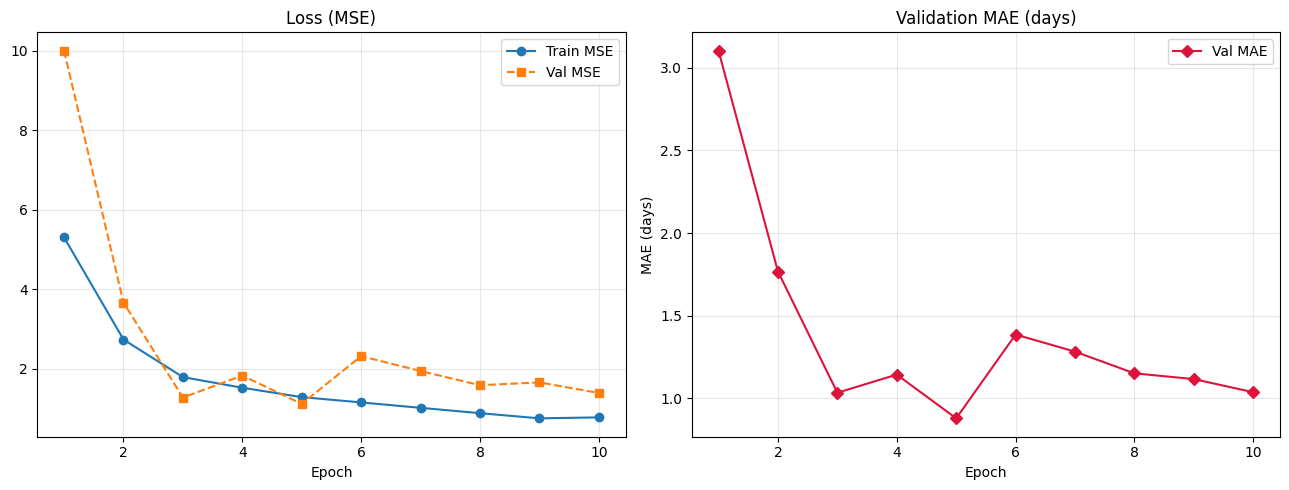

In [12]:
epochs = range(1, NUM_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(epochs, history['train_loss'], 'o-', label='Train MSE')
ax1.plot(epochs, history['val_loss'],   's--', label='Val MSE')
ax1.set_title('Loss (MSE)')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs, history['val_mae'], 'D-', color='crimson', label='Val MAE')
ax2.set_title('Validation MAE (days)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MAE (days)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Test 평가

In [13]:
model.eval()
test_loss = 0.0
all_preds  = []
all_labels = []

with torch.no_grad():
    for imgs, sensors, labels in test_loader:
        imgs, sensors, labels = imgs.to(device), sensors.to(device), labels.to(device)
        preds      = model(imgs, sensors)
        test_loss += criterion(preds, labels).item()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

test_mae  = np.abs(all_preds - all_labels).mean()
test_mse  = test_loss / len(test_loader)
test_rmse = np.sqrt(test_mse)

print(f'Test MSE : {test_mse:.4f}')
print(f'Test RMSE: {test_rmse:.4f} days')
print(f'Test MAE : {test_mae:.4f} days')

Test MSE : 6.9897
Test RMSE: 2.6438 days
Test MAE : 2.3747 days


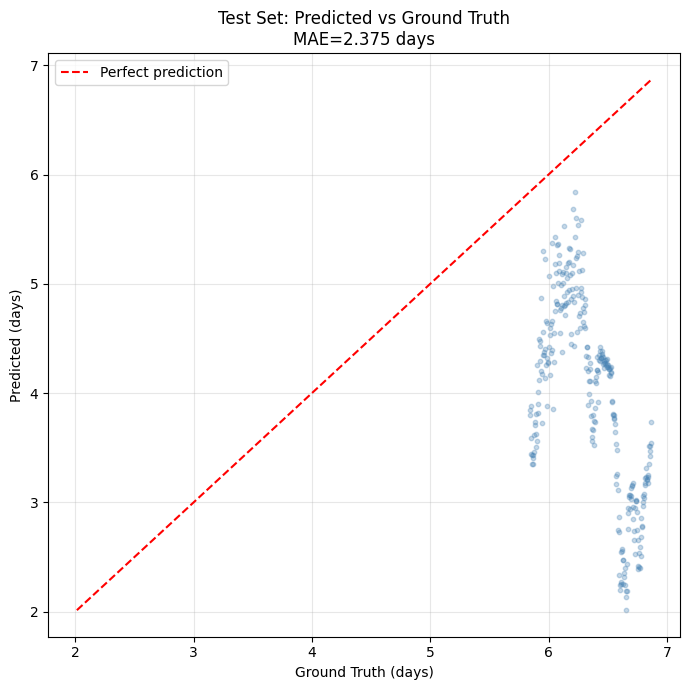

In [14]:
# Prediction vs Ground Truth scatter
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(all_labels, all_preds, alpha=0.3, s=10, color='steelblue')
lims = [min(all_labels.min(), all_preds.min()), max(all_labels.max(), all_preds.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Ground Truth (days)')
ax.set_ylabel('Predicted (days)')
ax.set_title(f'Test Set: Predicted vs Ground Truth\nMAE={test_mae:.3f} days')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. 랜덤 샘플 추론

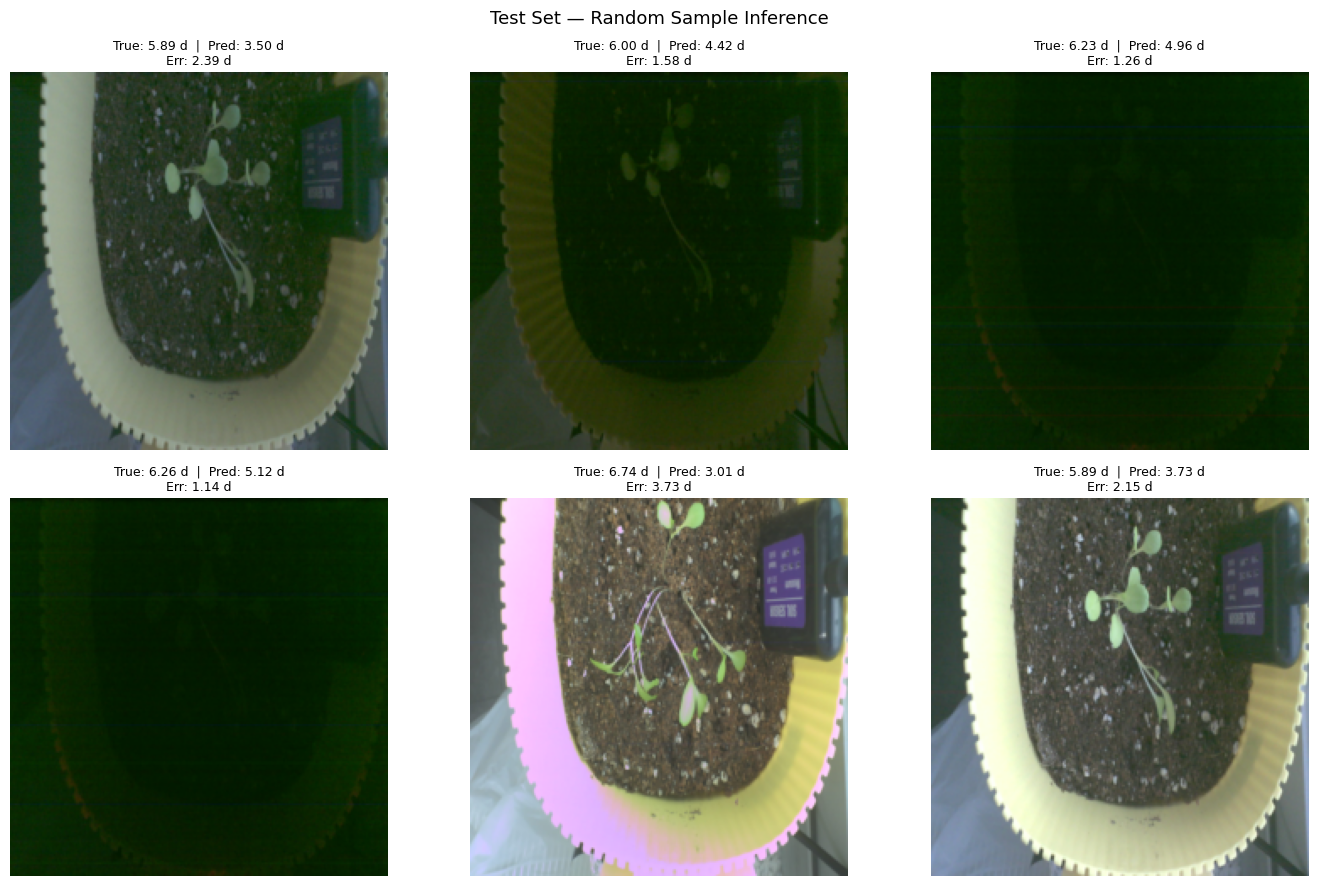

In [16]:
def denormalize(tensor: torch.Tensor) -> np.ndarray:
    mean = np.array(IMAGENET_MEAN)
    std  = np.array(IMAGENET_STD)
    img  = tensor.permute(1, 2, 0).cpu().numpy()
    img  = std * img + mean
    return np.clip(img, 0, 1)

model.eval()
sample_indices = random.sample(range(len(df_test)), 6)

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

with torch.no_grad():
    for ax, idx in zip(axes, sample_indices):
        img_t, sensor_t, label = test_ds[idx]
        pred = model(
            img_t.unsqueeze(0).to(device),
            sensor_t.unsqueeze(0).to(device)
        ).item()
        true = label.item()

        ax.imshow(denormalize(img_t))
        ax.set_title(
            f'True: {true:.2f} d  |  Pred: {pred:.2f} d\nErr: {abs(pred-true):.2f} d',
            fontsize=9
        )
        ax.axis('off')

plt.suptitle('Test Set — Random Sample Inference', fontsize=13)
plt.tight_layout()
plt.show()

## 10. 모델 저장

In [ ]:
CKPT_DIR = DATA_DIR.parent.parent / 'checkpoints'
CKPT_DIR.mkdir(parents=True, exist_ok=True)

ckpt_path = CKPT_DIR / 'collector_backbone.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'backbone': BACKBONE,
    'sensor_cols': SENSOR_COLS,
    'test_mae': float(test_mae),
    'test_rmse': float(test_rmse),
    'num_epochs': NUM_EPOCHS,
}, ckpt_path)

print(f'저장: {ckpt_path}')
print(f'Test MAE: {test_mae:.4f} days  |  RMSE: {test_rmse:.4f} days')